# 05 — Cognitive Load Reduction

> **"Every element in a chart either earns its place or steals attention from what matters."**

---

**Cognitive load** = lượng effort não bộ cần bỏ ra để hiểu một chart.

Chart phức tạp không phải là chart thông minh hơn — nó chỉ là chart **tốn nhiều effort hơn** để đọc.
Mỗi element thừa (gridline không cần thiết, legend xa data, tick label dày đặc)
đều là một "thuế" đánh vào người xem trước khi họ chạm được vào insight.

### Nội dung notebook này:

1. **Direct Labeling** — Xóa legend, đặt nhãn thẳng lên data
2. **Declutter** — Xóa chart junk: gridlines, spines, ticks thừa
3. **Inline Labels** — Label series ngay tại vị trí trên đường
4. **Label Max / Min** — Đánh dấu điểm quan trọng tự động
5. **Typography Hierarchy** — Title / subtitle / axis / caption đúng cỡ
6. **Theme System** — Clean / minimal / research / dark
7. **Data-Ink Ratio** — Nguyên tắc của Tufte
8. **Before / After Makeover** — Cùng data, chart tệ vs chart tốt

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import (
    format_thousands, format_percent,
    rotate_ticks, set_tick_style, set_axis_labels,
)
from vizint.annotation import (
    label_last_point, label_max, label_min,
    inline_series_labels,
    add_note, add_caption, add_source_note,
)
from vizint.styling import (
    apply_theme, set_global_theme,
    style_title, style_label,
    categorical_colors,
)
from vizint.styling.typography import (
    TITLE_SIZE, SUBTITLE_SIZE, AXIS_LABEL_SIZE,
    TICK_SIZE, ANNOTATION_SIZE, CAPTION_SIZE,
)
from vizint.perception import highlight_series, fade_series

np.random.seed(55)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo dữ liệu cho 4 product lines trong 24 tháng —
đủ để demo tất cả kỹ thuật declutter và direct labeling.

In [2]:
T = 24
months = np.arange(T)

products = {
    'Product A': 4200 + np.cumsum(np.random.randn(T) * 120 + 15),
    'Product B': 3100 + np.cumsum(np.random.randn(T) * 90  + 8),
    'Product C': 2400 + np.cumsum(np.random.randn(T) * 110 - 5),
    'Product D': 1800 + np.cumsum(np.random.randn(T) * 80  + 20),
}

# Single series for max/min demo
y_single = (
    500
    + np.linspace(0, 150, T)
    + 50 * np.sin(2 * np.pi * months / 12)
    + np.random.randn(T) * 20
)

# Month labels
month_names = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec',
] * 2

print('Products:', list(products.keys()))
print(f'Revenue range: [{min(v.min() for v in products.values()):.0f}, '
      f'{max(v.max() for v in products.values()):.0f}]')

Products: ['Product A', 'Product B', 'Product C', 'Product D']
Revenue range: [1862, 4629]


## 1. Direct Labeling — Xóa Legend

Legend yêu cầu người xem thực hiện nhiều bước:

1. tìm màu trong legend
2. ghi nhớ màu
3. quay lại chart
4. tìm series tương ứng

Quá trình này lặp lại cho mỗi series → tăng **cognitive load**.

Direct labeling đặt nhãn trực tiếp cạnh data, loại bỏ hoàn toàn bước trung gian.

Time series:

$$
y_t^{(i)}
$$

Label được đặt tại điểm cuối:

$$
(y_T^{(i)},\; \text{name}_i)
$$

---

### Label tại điểm cuối (last point)

Điểm tự nhiên nhất để đặt label:

$$
t = T
$$

vì:

- không che dữ liệu quá khứ
- dễ đọc trend
- gần vị trí hiện tại nhất

Label position:

$$
(x, y) = (T, y_T)
$$

---

### So sánh Legend vs Direct Label

Legend:

$$
\text{color} \rightarrow \text{series}
$$

Direct label:

$$
\text{series} \rightarrow y_T
$$

Direct label giảm:

- eye movement
- memory load
- confusion

---

### Lợi ích của Direct Labeling

#### 1. Giảm cognitive load

Không cần mapping:

$$
\text{color} \rightarrow \text{name}
$$

Label nằm trực tiếp cạnh đường.

---

#### 2. Đọc nhanh hơn

Người xem đọc:

- tên series
- giá trị cuối
- trend

trong một vị trí.

---

#### 3. Tránh legend clutter

Khi nhiều series:

Legend:

- dài
- khó đọc
- xa chart

Direct labeling:

- gọn
- gần data
- trực quan

---

#### 4. Tự nhiên với time series

Time series kết thúc tại:

$$
t = T
$$

Label tại đây không che dữ liệu.

---

### Khi nên dùng direct labeling

Phù hợp khi:

- line chart
- time series
- few-to-medium series
- không overlap mạnh

---

### Khi không nên dùng

Không phù hợp khi:

- quá nhiều series
- lines chồng nhau
- scatter dense

---

### Summary

Direct labeling đặt nhãn tại:

$$
(y_T, T)
$$

Thay vì legend:

$$
\text{color} \leftrightarrow \text{series}
$$

Giúp:

- giảm cognitive load
- đọc nhanh hơn
- loại bỏ legend
- trực quan hơn

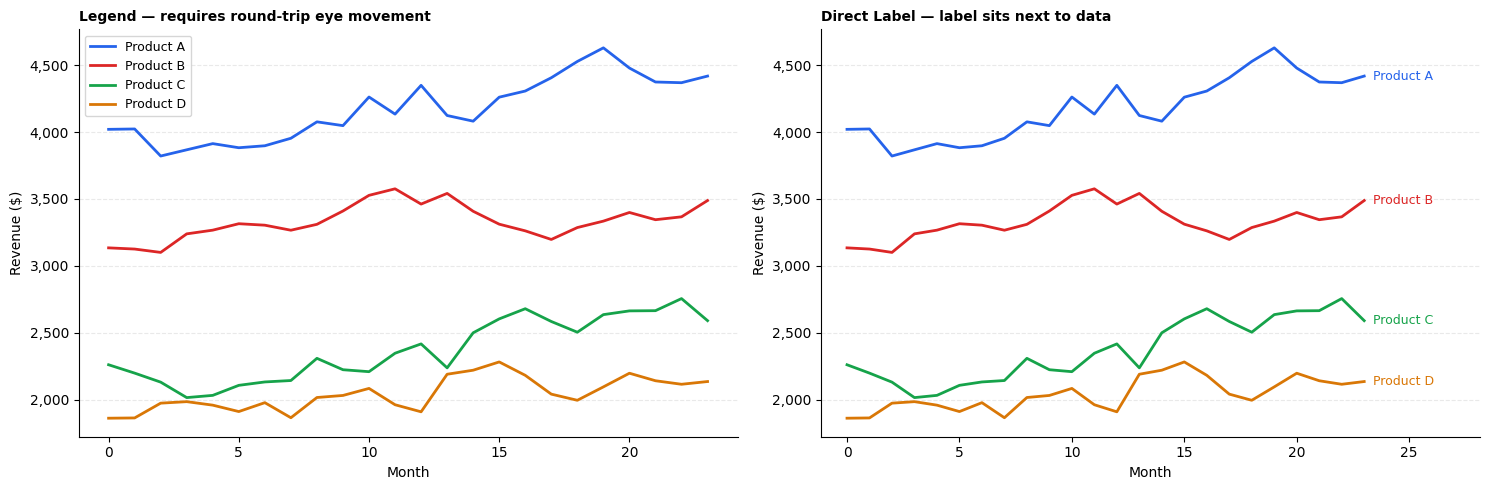

In [3]:
colors = categorical_colors(4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Legend (bad)
ax = axes[0]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
ax.legend(frameon=True, fontsize=9, loc='upper left')
ax.set_title('Legend — requires round-trip eye movement',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: Direct label (good)
ax = axes[1]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0)
    label_last_point(ax, months, y, text=name, color=c,
                     fontsize=9, offset_x=6)
ax.set_title('Direct Label — label sits next to data',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
# Expand x-axis to make room for labels
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 4)
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Direct Labeling — Legend vs Direct Labels

Multi-series time series:

$$
y_t^{(1)},\;
y_t^{(2)},\;
y_t^{(3)},\;
y_t^{(4)}
$$

Có hai cách annotate:

- legend mapping
- direct labeling

---

### Legend — Round-trip Eye Movement

Legend yêu cầu mapping:

$$
\text{color}_i
\rightarrow
\text{series}_i
$$

Người xem phải:

1. nhìn legend
2. ghi nhớ màu
3. quay lại chart
4. tìm line tương ứng

Lặp lại cho mỗi series:

$$
O(n)
$$

eye movement.

Khi $n$ tăng:

- khó đọc
- chậm
- dễ nhầm

---

### Direct Label — Label cạnh data

Direct label đặt tại:

$$
(T,\; y_T^{(i)})
$$

Label nằm ngay cạnh line:

$$
\text{name}_i \approx y_T^{(i)}
$$

Không cần mapping.

---

### So sánh cognitive load

Legend:

$$
\text{read}
\rightarrow
\text{map}
\rightarrow
\text{search}
$$

Direct label:

$$
\text{read directly}
$$

Direct labeling giảm:

- memory load
- eye movement
- search time

---

### Vì sao label tại điểm cuối tốt nhất

Time series kết thúc tại:

$$
t = T
$$

Đặt label tại:

$$
y_T
$$

Ưu điểm:

- không che data
- gần vị trí hiện tại
- đọc trend dễ

---

### Interpretation từ hình

Direct label cho phép đọc ngay:

- Product A cao nhất
- Product B second
- Product C tăng dần
- Product D thấp nhất

Không cần legend lookup.

---

### Khi nên dùng direct labeling

Phù hợp:

- line chart
- time series
- ít series
- lines không overlap nhiều

---

### Summary

Legend:

$$
\text{color} \leftrightarrow \text{series}
$$

Direct label:

$$
(T,\; y_T^{(i)})
$$

Giúp:

- loại bỏ legend
- giảm cognitive load
- đọc nhanh hơn
- trực quan hơn

## 2. Inline Series Labels

Inline labeling đặt nhãn **trực tiếp trên đường** tại một vị trí $x$ xác định,
thay vì chỉ ở điểm cuối.

Time series:

$$
y_t^{(i)}
$$

Label được đặt tại:

$$
(x^*,\; y^{(i)}(x^*))
$$

trong đó $x^*$ là vị trí mong muốn.

---

### Interpolation tại vị trí bất kỳ

Nếu $x^*$ không trùng với điểm dữ liệu:

$$
x_k < x^* < x_{k+1}
$$

Nội suy tuyến tính:

$$
y(x^*)
=
y_k
+
\frac{x^*-x_k}{x_{k+1}-x_k}
\left(
y_{k+1}-y_k
\right)
$$

Label được đặt tại:

$$
(x^*, y(x^*))
$$

---

### Khi inline labels hữu ích

#### 1. Series không kết thúc cùng thời điểm

Nếu:

$$
T_1 \ne T_2 \ne T_3
$$

Label cuối không còn thẳng hàng.

Inline label đặt tại:

$$
x = x^*
$$

giúp so sánh rõ.

---

#### 2. Nhấn mạnh divergence point

Nếu các series phân kỳ tại:

$$
x = x_d
$$

Đặt label tại:

$$
x^* = x_d
$$

Giúp highlight difference.

---

#### 3. Chart quá dài

Nếu:

$$
T \gg x_{\text{interesting}}
$$

Label cuối nằm quá xa phần chính.

Inline label đặt gần vùng quan tâm.

---

### Inline vs Last-point labeling

Last-point:

$$
(T,\; y_T)
$$

Inline:

$$
(x^*,\; y(x^*))
$$

Inline linh hoạt hơn.

---

### Lợi ích của inline labeling

#### Giảm eye travel

Label nằm gần dữ liệu:

$$
\text{name}_i \approx y^{(i)}(x^*)
$$

---

#### Nhấn mạnh vị trí quan trọng

Label tại:

- divergence
- crossover
- event time

---

#### Tốt cho chart dài

Không cần nhìn sang cuối chart.

---

### Summary

Inline label đặt tại:

$$
(x^*,\; y^{(i)}(x^*))
$$

với nội suy:

$$
y(x^*)
=
y_k
+
\frac{x^*-x_k}{x_{k+1}-x_k}
(y_{k+1}-y_k)
$$

Giúp:

- label giữa chart
- highlight divergence
- giảm eye movement
- linh hoạt hơn last-point labeling

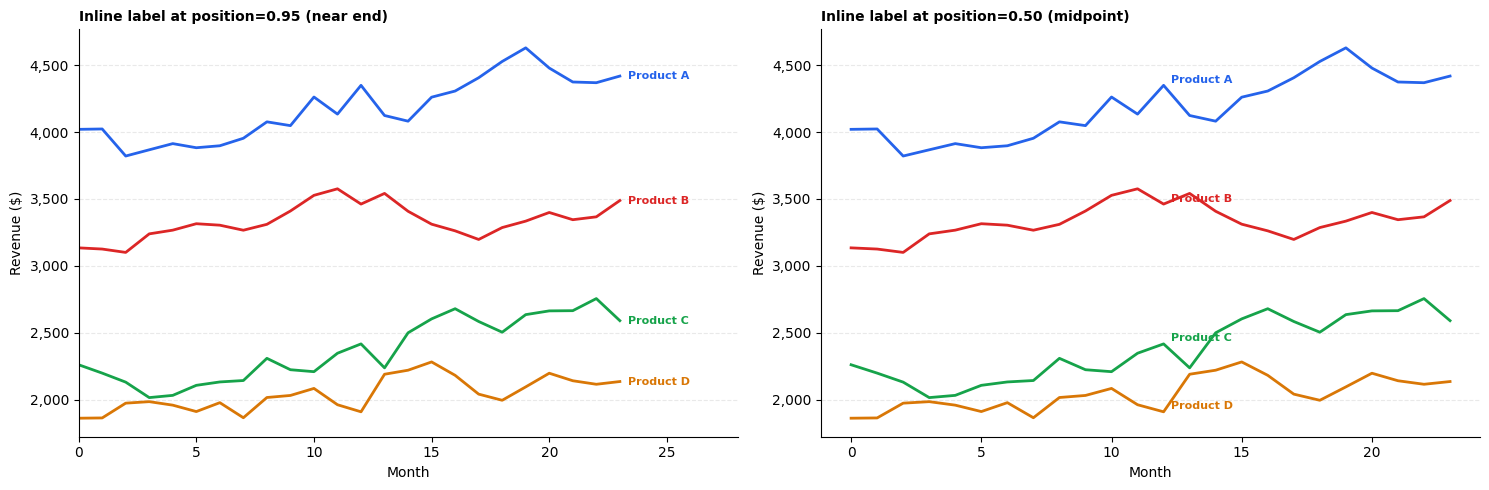

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

color_map = dict(zip(products.keys(), colors))

# Panel 1: label at end (position=1.0)
ax = axes[0]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
inline_series_labels(
    ax, months,
    series={k: v for k, v in products.items()},
    position=0.95,
    color_map=color_map,
    fontsize=8, offset=(6, 0),
)
ax.set_title('Inline label at position=0.95 (near end)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
ax.set_xlim(months[0], months[-1] + 5)
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: label at divergence point (position=0.5)
ax = axes[1]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
inline_series_labels(
    ax, months,
    series={k: v for k, v in products.items()},
    position=0.50,
    color_map=color_map,
    fontsize=8, offset=(5, 4),
)
ax.set_title('Inline label at position=0.50 (midpoint)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Inline Label Position — Near End vs Midpoint

So sánh hai cách đặt inline label:

- `position = 0.95` — gần cuối chart
- `position = 0.50` — giữa chart

---

### Near End (position = 0.95)

Ưu điểm:

- Ít che dữ liệu
- Gần giống last-point labeling
- Nhấn mạnh giá trị cuối

Nhược điểm:

- Labels bị dồn về bên phải
- Vẫn phải eye travel từ giữa → cuối chart
- Không highlight vùng divergence

Về bản chất, đây chỉ là **last-point labeling lùi vào một chút**.

---

### Midpoint (position = 0.50)

Ưu điểm lớn:

#### Labels nằm ngay vùng dữ liệu chính

Người đọc thường nhìn vào giữa chart trước.
Inline label đặt tại đây giúp:

- đọc nhanh hơn
- không cần nhìn sang phải
- giảm eye movement

---

#### Spacing giữa labels tốt hơn

Tại midpoint, các series thường tách nhau rõ:

- Product A
- Product B
- Product C
- Product D

Khoảng cách theo trục y lớn hơn → label ít overlap hơn.

---

#### Highlight divergence

Midpoint thường là nơi:

- series bắt đầu tách nhau
- trend trở nên rõ ràng
- differences dễ nhìn nhất

Đặt label tại đây giúp nhấn mạnh sự khác biệt.

---

#### Layout cân bằng hơn

Near-end:


chart ---------------- labels


Midpoint:


chart ----- labels ----- chart


Chart cân đối và dễ đọc hơn.

---

### Khi nên dùng Near End

Dùng `position ≈ 0.9` khi:

- quan tâm giá trị cuối
- chart nhiều series
- tránh label chồng lên nhau
- thay thế last-point labeling

---

### Khi nên dùng Midpoint

Dùng `position ≈ 0.5` khi:

- muốn so sánh các series
- highlight divergence
- chart dài
- storytelling

---

### Default tốt nhất

Trong thực tế:


position = 0.7


Lý do:

- không quá giữa
- không quá cuối
- ít overlap
- vẫn gần vùng quan trọng

---

### Summary

Midpoint tốt hơn vì:

- giảm eye movement
- highlight divergence
- spacing label tốt hơn
- layout cân bằng hơn

Near-end chỉ là **last-point labeling cải tiến nhẹ**.

## 3. Label Max / Min — Đánh dấu điểm quan trọng

Thay vì buộc người xem tự tìm đỉnh và đáy,
`label_max` và `label_min` tự động:

1. Tìm vị trí max/min bằng `np.nanargmax` / `np.nanargmin`
2. Đặt label với format tùy chỉnh
3. Offset để không đè lên data point

Có thể kết hợp với `highlight_points` để thêm marker tại đỉnh/đáy.

---

### 3.1 Ý tưởng

Với time series:

$$
y_t
$$

Điểm cực đại:

$$
t_{\max} = \operatorname*{arg\,max}_t y_t
$$

Giá trị tại đỉnh:

$$
y_{\max} = y_{t_{\max}}
$$

Label được đặt tại:

$$
\left(t_{\max},\, y_{\max}\right)
$$

---

Tương tự với cực tiểu:

$$
t_{\min} = \operatorname*{arg\,min}_t y_t
$$

$$
y_{\min} = y_{t_{\min}}
$$

Label:

$$
\left(t_{\min},\, y_{\min}\right)
$$

---

### 3.2 Offset để tránh đè lên point

Label không đặt đúng lên điểm mà dịch nhẹ.

Max:

$$
\left(
t_{\max},
y_{\max} + \Delta_y
\right)
$$

Min:

$$
\left(
t_{\min},
y_{\min} - \Delta_y
\right)
$$

Trong đó:

$$
\Delta_y = \alpha \cdot (y_{\max} - y_{\min})
$$

Thường chọn:


α = 0.02 → 0.05


---

### 3.3 Multi-series case

Cho nhiều series:

$$
y_t^{(i)}
$$

Mỗi series có:

$$
t_{\max}^{(i)} = \operatorname*{arg\,max}_t y_t^{(i)}
$$

Label:

$$
\left(
t_{\max}^{(i)},
y_{\max}^{(i)}
\right)
$$

Giúp tự động annotate từng đường.

---

### 3.4 Label max vs inline label

Inline label:

$$
(x^*,\, y(x^*))
$$

Label max:

$$
(t_{\max},\, y_{\max})
$$

Inline → label tại vị trí cố định
Max → label tại vị trí quan trọng nhất

---

### 3.5 Label max vs last-point

Last point:

$$
(T, y_T)
$$

Max point:

$$
(t_{\max}, y_{\max})
$$

Label max trả lời:

- peak ở đâu
- giá trị cao nhất
- thời điểm quan trọng

---

### 3.6 Khi nên dùng

Use `label_max` khi:

- highlight peak
- spike detection
- best performance
- highest value

Use `label_min` khi:

- drawdown
- trough
- worst case
- lowest value

---

### 3.7 Summary

Label max:

$$
(t_{\max}, y_{\max})
$$

Label min:

$$
(t_{\min}, y_{\min})
$$

Giúp:

- tự động tìm peak
- highlight điểm quan trọng
- giảm annotate thủ công
- tốt cho storytelling

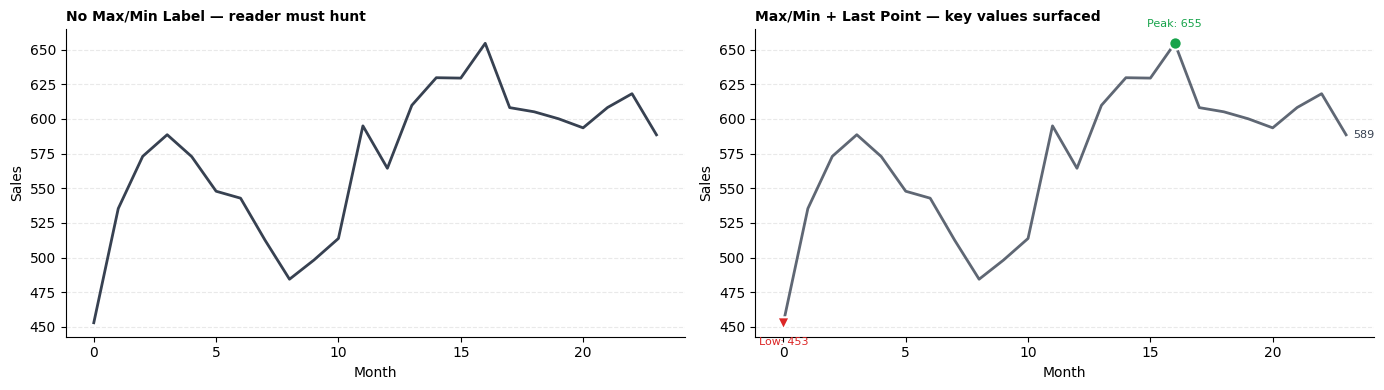

In [5]:
from vizint.perception import highlight_points

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: No labels — reader must hunt
ax = axes[0]
ax.plot(months, y_single, color='#374151', linewidth=2.0)
ax.set_title('No Max/Min Label — reader must hunt',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: With max/min labels
ax = axes[1]
ax.plot(months, y_single, color='#374151', linewidth=2.0, alpha=0.8)

# Max
label_max(ax, months, y_single,
          fmt='Peak: {:,.0f}',
          color='#16A34A', fontsize=8, offset=(0, 10))
idx_max = int(np.nanargmax(y_single))
highlight_points(ax, [months[idx_max]], [y_single[idx_max]],
                 color='#16A34A', size=80, edgecolor='white')

# Min
label_min(ax, months, y_single,
          fmt='Low: {:,.0f}',
          color='#DC2626', fontsize=8, offset=(0, -10))
idx_min = int(np.nanargmin(y_single))
highlight_points(ax, [months[idx_min]], [y_single[idx_min]],
                 color='#DC2626', size=80, marker='v', edgecolor='white')

# Last point value
label_last_point(ax, months, y_single,
                 fmt='{:,.0f}', color='#374151', fontsize=8)

ax.set_title('Max/Min + Last Point — key values surfaced',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

### Label Max / Min — Why It Matters

Không có max/min label, người đọc phải tự tìm:

- điểm cao nhất
- điểm thấp nhất
- giá trị cuối

Điều này làm tăng **cognitive load** và chậm quá trình đọc chart.

---

### Without Max/Min Labels

Người đọc phải:

- quét toàn bộ đường
- ước lượng peak
- ước lượng trough
- đọc trục y để đo value

Quy trình này:


scan → compare → estimate → confirm


Chậm và dễ sai.

---

### With Max/Min Labels

Chart tự hiển thị:

- Peak value
- Lowest value
- Last value

Người đọc thấy ngay:

- điểm quan trọng
- magnitude
- thời điểm

Không cần "hunt".

---

### Visual Hierarchy

Max / Min labels tạo hierarchy:

1. Peak — quan trọng nhất
2. Trough — rủi ro / đáy
3. Last point — trạng thái hiện tại

Chart trở thành:


trend + key values


thay vì chỉ:


trend only


---

### Khi Max/Min đặc biệt hữu ích

#### Performance charts

- revenue peak
- best month
- highest users

#### Risk charts

- drawdown bottom
- worst loss
- min liquidity

#### Monitoring charts

- spike detection
- anomaly highlight
- regime change

---

### Kết hợp với Last Point

Max / Min trả lời:

- cao nhất là bao nhiêu
- thấp nhất là bao nhiêu

Last point trả lời:

- hiện tại ở đâu

Ba điểm quan trọng:

$$
(t_{\min}, y_{\min})
\quad
(t_{\max}, y_{\max})
\quad
(T, y_T)
$$

Tạo complete narrative:

- started low
- peaked here
- ended here

---

### Khi không nên dùng

Không nên label max/min khi:

- data quá noisy
- nhiều spike nhỏ
- chart rất dày

Vì sẽ tạo clutter.

Khi đó nên dùng:

- smoothed series
- rolling max
- percentile label

---

### Summary

Label max/min giúp:

- giảm cognitive load
- highlight key values
- tăng readability
- tạo narrative
- tránh người đọc phải hunt peak

## 4. Declutter — Xóa Chart Junk

**Chart junk** (Edward Tufte) = mọi "ink" không encode data:

- Gridlines quá dày
- Tất cả 4 spines (viền)
- Tick marks không cần thiết
- Background color khác trắng
- 3D effects
- Drop shadows

Mục tiêu của declutter:

- tăng data-to-ink ratio
- giảm visual noise
- làm nổi bật data
- cải thiện readability

---

### 4.1 Data-Ink Ratio

Theo Tufte:

$$
\text{Data-Ink Ratio}
=
\frac{\text{Ink used for data}}
{\text{Total ink used}}
$$

Declutter nhằm:

$$
\text{maximize Data-Ink Ratio}
$$

Giữ:

- data lines
- markers quan trọng
- labels

Loại bỏ:

- decoration
- heavy grid
- borders
- background

---

### 4.2 Các loại Chart Junk phổ biến

#### Heavy gridlines

Gridlines đậm cạnh tranh với data.

Trước:

- grid dày
- màu đậm
- nhiều lines

Sau:

- grid mỏng
- màu nhạt
- hoặc bỏ hoàn toàn

---

#### Full spines

Matplotlib mặc định có 4 viền:

- top
- right
- left
- bottom

Nhưng thường chỉ cần:

- left
- bottom

Hoặc thậm chí chỉ:

- bottom

---

#### Excess ticks

Tick quá nhiều tạo noise:

- minor ticks dày
- tick labels sát nhau
- trục x quá chi tiết

Declutter:

- giảm tick count
- chỉ giữ major ticks
- xoá tick marks

---

#### Background color

Background không trắng:

- làm giảm contrast
- cạnh tranh với data
- khó đọc

Best practice:

- background trắng
- hoặc rất nhạt

---

#### 3D effects

3D:

- không thêm thông tin
- làm méo perception
- khó so sánh

Tufte: tránh 3D nếu không encode dimension mới.

---

#### Drop shadows

Shadow:

- purely decorative
- tăng clutter
- không encode data

Nên loại bỏ.

---

### 4.3 Before vs After Declutter

Before:

- heavy grid
- 4 spines
- background xám
- ticks dày
- line mờ

After:

- minimal grid
- 2 spines hoặc none
- background trắng
- ticks ít
- line nổi bật

---

### 4.4 Minimal chart principles

Giữ lại:

- data line
- axis label
- title
- key annotations

Loại bỏ:

- box
- shadow
- heavy grid
- decoration

---

### 4.5 Declutter không có nghĩa là bỏ hết

Sai:

- xoá hết grid
- xoá ticks
- xoá axis

Đúng:

- giữ những gì giúp đọc value
- bỏ những gì không cần

---

### 4.6 Practical rule

Good default:

- remove top/right spines
- light y-grid
- no x-grid
- white background
- limited ticks

---

### Summary

Declutter giúp:

- tăng data-ink ratio
- giảm visual noise
- highlight data
- cải thiện readability

Nguyên tắc:

> remove non-data ink, keep data ink

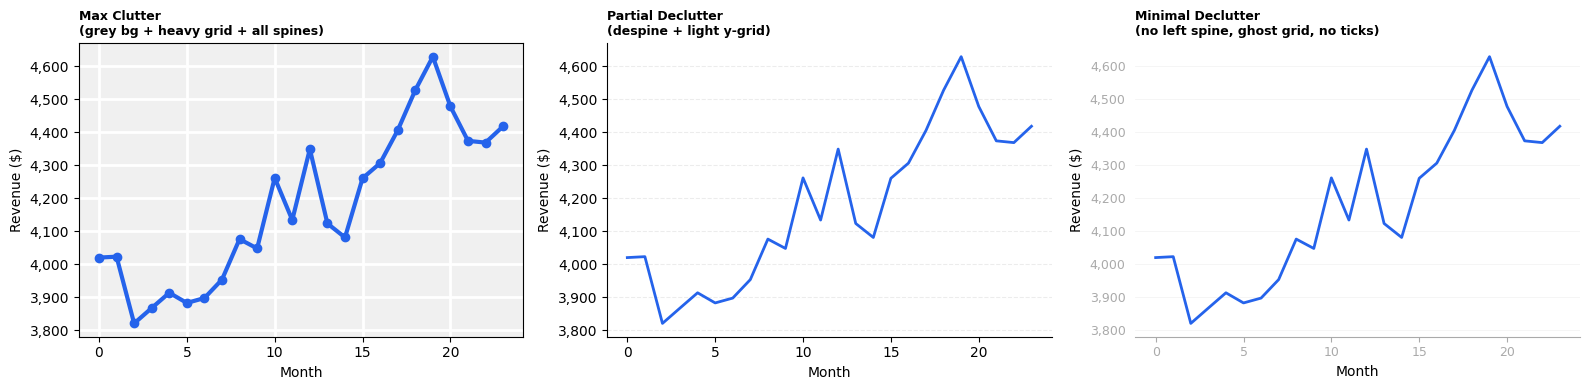

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

y_demo = list(products.values())[0]
c_demo = colors[0]

# Level 1: Maximum clutter
ax = axes[0]
ax.set_facecolor('#F0F0F0')
ax.grid(True, color='white', linewidth=2.0, which='both')
ax.plot(months, y_demo, color=c_demo, linewidth=3.0,
        marker='o', markersize=6)
ax.set_title('Max Clutter\n(grey bg + heavy grid + all spines)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
# Deliberately keep all spines

# Level 2: Partial declutter
ax = axes[1]
ax.plot(months, y_demo, color=c_demo, linewidth=2.0)
despine(ax)             # remove top + right
set_grid(ax, which='y', color='#e0e0e0', linewidth=0.8, alpha=0.6)
ax.set_title('Partial Declutter\n(despine + light y-grid)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')

# Level 3: Minimal
ax = axes[2]
ax.plot(months, y_demo, color=c_demo, linewidth=2.0)
despine(ax, left=True)  # remove top + right + left
ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.6, linestyle='-', alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(left=False)  # remove y tick marks
ax.set_title('Minimal Declutter\n(no left spine, ghost grid, no ticks)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
set_tick_style(ax, color='#aaaaaa', labelsize=9)

plt.tight_layout()
plt.show()

### Declutter Levels — Max vs Partial vs Minimal

Cùng một dataset nhưng mức độ clutter khác nhau tạo trải nghiệm đọc rất khác.

---

### Max Clutter

Bao gồm:

- background xám
- gridlines đậm
- cả 4 spines
- markers trên mọi điểm
- ticks đầy đủ

Kết quả:

- data bị chìm trong grid
- mắt bị phân tán
- khó thấy trend chính
- visual noise cao

Data-to-ink ratio thấp:

$$
\text{data ink} \ll \text{non-data ink}
$$

---

### Partial Declutter

Giảm bớt clutter:

- bỏ top/right spines
- grid nhẹ hơn
- bỏ markers
- background trắng

Kết quả:

- trend rõ hơn
- ít distraction
- vẫn giữ reference grid

Đây là mức **default tốt** cho hầu hết chart.

---

### Minimal Declutter

Chỉ giữ:

- data line
- axis label
- rất ít grid (ghost grid)
- gần như không ticks

Loại bỏ:

- left spine
- tick marks
- heavy grid
- decoration

Kết quả:

- data nổi bật nhất
- cực kỳ clean
- phù hợp presentation

Data-to-ink ratio cao:

$$
\text{data ink} \approx \text{total ink}
$$

---

### Ghost Grid

Minimal declutter thường dùng ghost grid:

- rất mờ
- chỉ giúp ước lượng value
- không cạnh tranh với data

Opacity thường:


alpha = 0.1 → 0.2


---

### Khi dùng từng mức

Use **Max clutter** khi:

- debug chart
- cần đọc value chính xác
- exploratory analysis

Use **Partial declutter** khi:

- dashboard
- report
- notebook

Use **Minimal declutter** khi:

- presentation
- storytelling
- highlight trend

---

### Visual hierarchy

Clutter nhiều:


grid > axes > data


Declutter:


data > grid > axes


Minimal:


data >> everything


---

### Summary

Declutter giúp:

- giảm visual noise
- tăng readability
- highlight trend
- tăng data-ink ratio

Ba mức:

- Max clutter → nhiều reference, nhiều noise
- Partial → cân bằng
- Minimal → sạch nhất, data nổi bật nhất

## 5. Number Formatting

Tick labels không được format tốt là một dạng **cognitive load ẩn**:

- `4200` → khó đọc hơn `4,200`
- `0.0652` → khó đọc hơn `6.5%`
- `1500000` → khó đọc hơn `1.5M`

`format_thousands` và `format_percent` áp dụng formatter trực tiếp trên axis.
Có thể viết custom formatter với `FuncFormatter`.

---

### 5.1 Mục tiêu của number formatting

Number formatting giúp:

- giảm cognitive load
- tăng readability
- rút ngắn tick labels
- nhất quán đơn vị

Không đổi data — chỉ đổi **presentation**.

---

### 5.2 Thousands separator

Không format:


- 4200
- 12500
- 138000


Format:


- 4,200
- 12,500
- 138,000


Giúp đọc magnitude nhanh hơn.

Biến đổi:

$$
x \rightarrow \text{format}(x, ",")
$$

---

### 5.3 Percent formatting

Data dạng:

$$
p \in [0,1]
$$

Hiển thị:

$$
100p \%
$$

Ví dụ:


- 0.0652 → 6.52%
- 0.12 → 12%
- 0.8 → 80%


Biến đổi:

$$
p \rightarrow 100p
$$

kèm ký hiệu `%`.

---

### 5.4 Large number shortening

Rút gọn số lớn:

| Raw | Format |
|-----|--------|
| 1,500 | 1.5K |
| 1,500,000 | 1.5M |
| 2,300,000,000 | 2.3B |

Quy tắc:

$$
x =
\begin{cases}
x / 10^3 & \text{K} \\
x / 10^6 & \text{M} \\
x / 10^9 & \text{B}
\end{cases}
$$

---

### 5.5 Khi nên dùng từng loại

Use thousands:

- revenue
- sales
- users
- counts

Use percent:

- conversion rate
- growth rate
- accuracy
- probability

Use K/M/B:

- population
- market cap
- traffic
- downloads

---

### 5.6 Custom formatter

General form:

$$
x \rightarrow f(x)
$$

Trong đó:

- `x` là tick value
- `f(x)` là string hiển thị

Ví dụ:


- 4200 → "$4.2K"


Hoặc:


- 0.034 → "3.4 pp"


---

### 5.7 Formatting tốt vs xấu

Bad:


- 4200
- 4300
- 4400
- 4500


Better:


- 4,200
- 4,300
- 4,400
- 4,500


Best (compact):


- 4.2K
- 4.3K
- 4.4K
- 4.5K


---

### 5.8 Formatting và declutter

Number formatting cũng là declutter:

Trước:


- 1500000
- 2000000
- 2500000


Sau:


- 1.5M
- 2.0M
- 2.5M


Tick ngắn hơn → chart sạch hơn.

---

### Summary

Number formatting giúp:

- giảm cognitive load
- rút ngắn tick labels
- tăng readability
- nhất quán đơn vị

Các loại phổ biến:

- thousands separator
- percent formatting
- K / M / B shorthand
- custom formatter

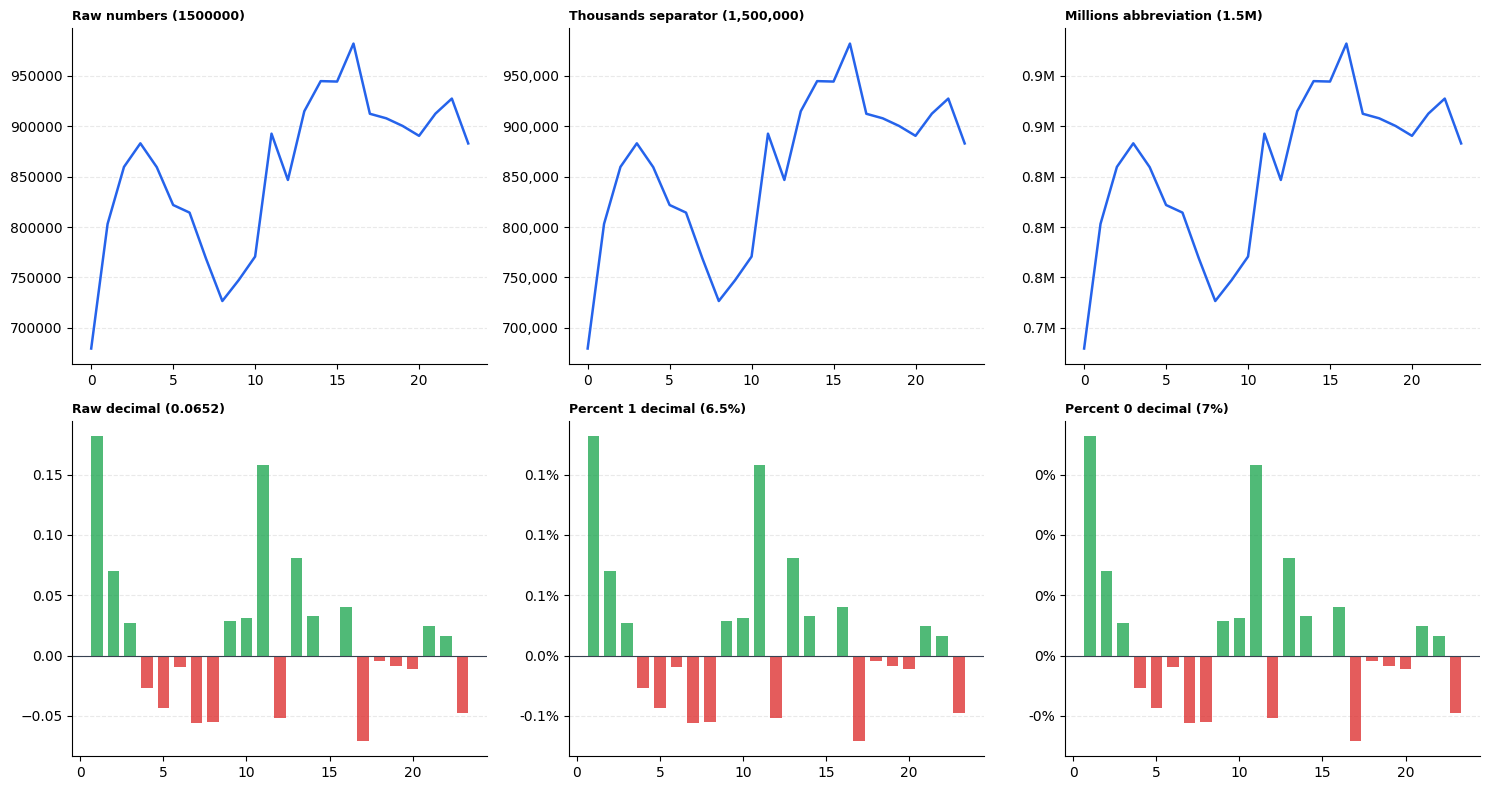

In [7]:
# Data có giá trị lớn và percentage
y_millions = y_single * 1500   # scale to millions
y_pct      = y_single / y_single.max()  # normalize to [0,1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='white')

# Row 1: Large numbers
titles_top = [
    'Raw numbers (1500000)',
    'Thousands separator (1,500,000)',
    'Millions abbreviation (1.5M)',
]
for ax, title in zip(axes[0], titles_top):
    ax.plot(months, y_millions, color='#2563EB', linewidth=1.8)
    ax.set_title(title, loc='left', fontsize=9, fontweight='bold')
    despine(ax); set_grid(ax)

# Apply formatters
# axes[0][0]: no formatter (raw)
# axes[0][1]: thousands
format_thousands(axes[0][1], 'y')
# axes[0][2]: millions custom
axes[0][2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

# Row 2: Percentages
y_growth = np.diff(y_single) / y_single[:-1]  # month-over-month growth
months_diff = months[1:]

titles_bot = [
    'Raw decimal (0.0652)',
    'Percent 1 decimal (6.5%)',
    'Percent 0 decimal (7%)',
]
for ax, title in zip(axes[1], titles_bot):
    ax.bar(months_diff, y_growth,
           color=['#16A34A' if v >= 0 else '#DC2626' for v in y_growth],
           alpha=0.75, width=0.7)
    ax.axhline(0, color='#374151', linewidth=0.8)
    ax.set_title(title, loc='left', fontsize=9, fontweight='bold')
    despine(ax); set_grid(ax)

# axes[1][0]: raw decimal
# axes[1][1]: 1 decimal percent
format_percent(axes[1][1], 'y', decimals=1)
# axes[1][2]: 0 decimal percent
format_percent(axes[1][2], 'y', decimals=0)

plt.tight_layout()
plt.show()

### Number Formatting — Raw vs Thousands vs Millions

Cùng một dataset nhưng cách format số khác nhau ảnh hưởng lớn đến readability.

---

### Raw numbers

Tick labels:


- 1500000
- 900000
- 850000


Vấn đề:

- nhiều chữ số
- khó đọc nhanh
- khó so sánh magnitude
- tăng cognitive load

Người đọc phải tự nhóm số:


> 1500000 → 1.5 million


---

### Thousands separator

Format:


- 1,500,000
- 900,000
- 850,000


Cải thiện:

- dễ đọc hơn
- tách magnitude rõ ràng
- không đổi đơn vị

Biến đổi:

$$
x \rightarrow \text{format}(x, ",")
$$

Đây là **improvement tối thiểu** nên dùng mặc định.

---

### Millions abbreviation

Format:


- 1.5M
- 0.9M
- 0.85M


Cải thiện:

- tick labels ngắn hơn
- chart sạch hơn
- đọc nhanh hơn

Biến đổi:

$$
x \rightarrow \frac{x}{10^6}
$$

kèm suffix:

$$
\text{M}
$$

---

### Decimal vs Percent

Raw decimal:


- 0.0652
- 0.12
- -0.034


Khó đọc vì:

- không trực quan
- phải nhân 100 trong đầu

Percent format:


- 6.5%
- 12%
- -3.4%


Biến đổi:

$$
p \rightarrow 100p
$$

---

### Decimal precision

Percent 1 decimal:


- 6.5%
- 2.3%
- -1.1%


Percent 0 decimal:


- 7%
- 2%
- -1%


Tradeoff:

- 1 decimal → chính xác hơn
- 0 decimal → sạch hơn

---

### Khi dùng từng loại

Use raw:

- debug
- scientific plots
- exact values

Use thousands:

- default choice
- finance
- dashboards

Use millions:

- số rất lớn
- presentation
- declutter

Use percent:

- rates
- returns
- probabilities

---

### Formatting và declutter

Shorter ticks:


> 1500000 -> 1.5M


Giảm:

- label width
- visual noise
- chart clutter

---

### Summary

Number formatting cải thiện:

- readability
- comparison
- declutter
- perception

Thứ tự tốt hơn:


> raw < thousands < millions


Và:


> decimal < percent

## 6. Typography Hierarchy

Typography tốt tạo ra **reading order** tự nhiên:

Title → Subtitle → Axis label → Annotation → Tick labels → Caption → Source

Người xem đọc chart theo thứ tự này mà không cần hướng dẫn.

---

### 6.1 Visual hierarchy

Typography tạo hierarchy bằng:

- font size
- font weight
- color contrast
- spacing

Nguyên tắc:

$$
\text{importance} \uparrow
\quad \Rightarrow \quad
\text{size} \uparrow
$$

và:

$$
\text{importance} \uparrow
\quad \Rightarrow \quad
\text{contrast} \uparrow
$$

---

### 6.2 vizint typography scale

| Element | Size | Weight | Color |
|---------|------|--------|-------|
| Title | 16 | bold | #1a1a1a |
| Subtitle | 12 | normal | #555555 |
| Axis label | 11 | normal | #444444 |
| Tick label | 10 | normal | #888888 |
| Annotation | 9 | normal | #1a1a1a |
| Caption | 8 | normal | #888888 |
| Source | 8 | normal | #9CA3AF |

---

### 6.3 Title

Title là entry point của chart:

- lớn nhất
- đậm nhất
- contrast cao nhất

Mục tiêu:

- truyền message chính
- không chỉ mô tả chart

Good:


Revenue grew steadily after Q3


Bad:


Revenue by month


---

### 6.4 Subtitle

Subtitle cung cấp context:

- timeframe
- unit
- scope
- note quan trọng

Ví dụ:


Monthly revenue, 2022–2024, USD


Subtitle nhỏ hơn title nhưng vẫn dễ đọc.

---

### 6.5 Axis labels

Axis label:

- nhỏ hơn subtitle
- không đậm
- màu trung tính

Không nên cạnh tranh với title.

Ví dụ:


Month
Revenue ($)


---

### 6.6 Tick labels

Tick labels là **reference**, không phải focus.

Vì vậy:

- font nhỏ
- màu nhạt
- không bold

Giảm visual noise.

---

### 6.7 Annotations

Annotation dùng để highlight:

- peak
- event
- change point

Nên:

- nhỏ hơn axis label
- nhưng contrast cao
- gần data

---

### 6.8 Caption

Caption:

- giải thích thêm
- note assumptions
- clarify methodology

Không nên nổi bật.

---

### 6.9 Source

Source là element ít quan trọng nhất:

- nhỏ nhất
- màu nhạt nhất
- đặt góc dưới

Ví dụ:


Source: Company internal data


---

### 6.10 Typography hierarchy tốt

Good hierarchy:


Title
Subtitle
Chart
Annotation
Axis labels
Ticks
Caption
Source


Bad hierarchy:

- tất cả font giống nhau
- tất cả màu giống nhau
- không có reading order

---

### Summary

Typography hierarchy giúp:

- tạo reading order
- giảm cognitive load
- highlight message chính
- tăng readability

Nguyên tắc:

- quan trọng → lớn hơn
- phụ → nhỏ hơn
- reference → nhạt hơn  

vizint Typography Scale:
  Title      : 16pt bold
  Subtitle   : 12pt normal
  Axis label : 11pt normal
  Tick       : 10pt normal
  Annotation : 9pt normal
  Caption    : 8pt normal


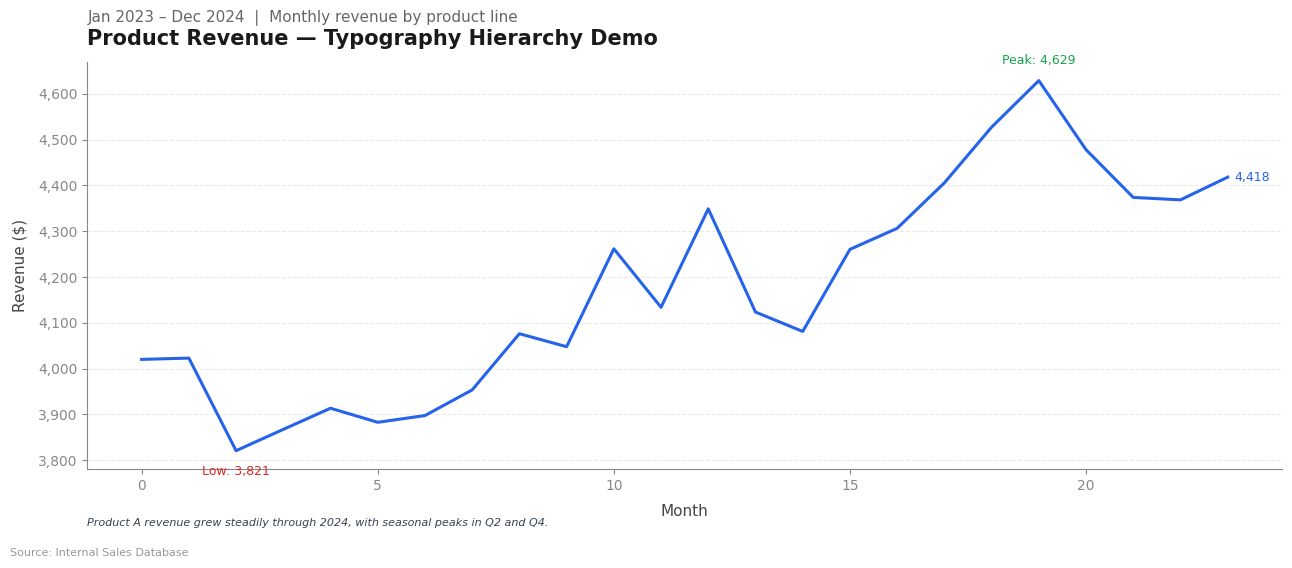

In [8]:
from vizint.annotation.notes import add_source_note

print('vizint Typography Scale:')
print(f'  Title      : {TITLE_SIZE}pt bold')
print(f'  Subtitle   : {SUBTITLE_SIZE}pt normal')
print(f'  Axis label : {AXIS_LABEL_SIZE}pt normal')
print(f'  Tick       : {TICK_SIZE}pt normal')
print(f'  Annotation : {ANNOTATION_SIZE}pt normal')
print(f'  Caption    : {CAPTION_SIZE}pt normal')

chart = (
    ChartBuilder(figsize=(13, 5.5))
    .set_title('Product Revenue — Typography Hierarchy Demo')
    .set_subtitle('Jan 2023 – Dec 2024  |  Monthly revenue by product line')
    .set_source('Internal Sales Database')
    .build()
)
ax = chart.ax

y_a = list(products.values())[0]
ax.plot(months, y_a, color='#2563EB', linewidth=2.2)

# Label max with ANNOTATION_SIZE
label_max(ax, months, y_a, fmt='Peak: {:,.0f}',
          color='#16A34A', fontsize=ANNOTATION_SIZE)
label_min(ax, months, y_a, fmt='Low: {:,.0f}',
          color='#DC2626', fontsize=ANNOTATION_SIZE)
label_last_point(ax, months, y_a, fmt='{:,.0f}',
                 color='#2563EB', fontsize=ANNOTATION_SIZE)

# Caption
add_caption(
    ax,
    'Product A revenue grew steadily through 2024, '
    'with seasonal peaks in Q2 and Q4.',
    fontsize=CAPTION_SIZE,
)

# Axis labels
set_axis_labels(ax, xlabel='Month', ylabel='Revenue ($)',
                fontsize=AXIS_LABEL_SIZE)
format_thousands(ax, 'y')
set_tick_style(ax, color='#888888', labelsize=TICK_SIZE)

plt.tight_layout()
plt.show()

### Typography Hierarchy — Example

Typography tốt tạo ra reading order tự nhiên.
Người xem đọc theo thứ tự:

Title → Subtitle → Chart → Annotation → Axis → Caption → Source

Chart trên minh họa hierarchy này.

---

### Title — Primary focus

- lớn nhất
- bold
- contrast cao
- truyền message chính

Product Revenue — Typography Hierarchy Demo

---

### Subtitle — Context

Subtitle cung cấp:

- timeframe
- scope
- unit
- mô tả ngắn

Jan 2023 – Dec 2024 | Monthly revenue by product line

Nhỏ hơn title và màu nhạt hơn.

---

### Axis labels — Structure

Axis labels giúp hiểu cấu trúc chart:

- Month
- Revenue ($)

Font nhỏ hơn subtitle và không bold.

---

### Tick labels — Reference only

Tick labels chỉ là reference:

- nhỏ
- màu nhạt
- không cạnh tranh với data

Ví dụ:

4,000
4,200
4,400

---

### Annotation — Highlight data

Annotations dùng để nhấn mạnh:

Peak: 4,629
Low: 3,821
Last: 4,418

Annotation nhỏ nhưng contrast cao và gần data.

---

### Caption — Interpretation

Caption cung cấp narrative:

Product A revenue grew steadily through 2024, with seasonal peaks in Q2 and Q4.

Font nhỏ và ít nổi bật.

---

### Source — Least important

Source đặt cuối và màu nhạt nhất:

Source: Internal Sales Database

---

### Visual hierarchy

Hierarchy tốt:

Title
Subtitle
Chart
Annotations
Axis labels
Ticks
Caption
Source

---

### Summary

Typography hierarchy giúp:

- tạo reading order
- giảm cognitive load
- highlight message chính
- cải thiện readability

Nguyên tắc:

quan trọng hơn → lớn hơn
phụ trợ → nhỏ hơn
reference → nhạt hơn

## 7. Theme System

vizint có 4 built-in themes — mỗi theme tối ưu cho một ngữ cảnh khác nhau:

| Theme | Dùng cho |
|-------|----------|
| clean | Presentation, dashboard — white bg, light grid |
| minimal | Print, report — rất ít decoration |
| research | Academic paper — slightly off-white, heavier grid |
| dark | Dark mode dashboard, screen display |

apply_theme(ax, theme) áp dụng theme cho một axes cụ thể.
set_global_theme(theme) áp dụng theme cho toàn bộ session.

---

### 7.1 Mục tiêu của theme system

Theme giúp:

- nhất quán style
- tránh lặp lại code styling
- chuyển đổi nhanh giữa contexts
- đảm bảo readability

Thay vì:

set từng:

- background
- grid
- spine
- tick color
- font color

chỉ cần đổi theme.

---

### 7.2 Clean theme

Đặc điểm:

- background trắng
- grid nhẹ
- spines tối thiểu
- màu trung tính

Phù hợp:

- presentation
- dashboard
- notebook

Mục tiêu:

- cân bằng giữa clarity và reference

---

### 7.3 Minimal theme

Đặc điểm:

- gần như không grid
- ít ticks
- không decoration
- data nổi bật

Phù hợp:

- print
- report
- storytelling

Data-to-ink ratio cao:

giữ data
loại bỏ decoration

---

### 7.4 Research theme

Đặc điểm:

- background hơi off-white
- grid rõ hơn
- ticks đầy đủ
- reference mạnh

Phù hợp:

- academic paper
- analysis
- scientific plots

Ưu tiên:

đọc value chính xác hơn là aesthetic.

---

### 7.5 Dark theme

Đặc điểm:

- background tối
- text sáng
- grid mờ
- line màu sáng

Phù hợp:

- dark dashboards
- screen display
- presentation tối

Giảm:

- eye strain
- glare

---

### 7.6 Axes vs Global theme

Axes theme:

áp dụng cho một chart:

apply_theme(ax, theme)

Hữu ích khi:

- nhiều chart khác theme
- comparison

---

Global theme:

set toàn bộ session:

set_global_theme(theme)

Hữu ích khi:

- notebook thống nhất
- dashboard
- report

---

### 7.7 Theme consistency

Một project nên dùng:

- một theme chính
- một theme phụ nếu cần

Tránh:

- mỗi chart một style
- inconsistent fonts
- inconsistent grid

---

### Summary

Theme system giúp:

- style nhất quán
- chuyển context nhanh
- giảm code styling
- cải thiện readability

Bốn themes:

clean → presentation
minimal → report
research → academic
dark → dashboard dark mode

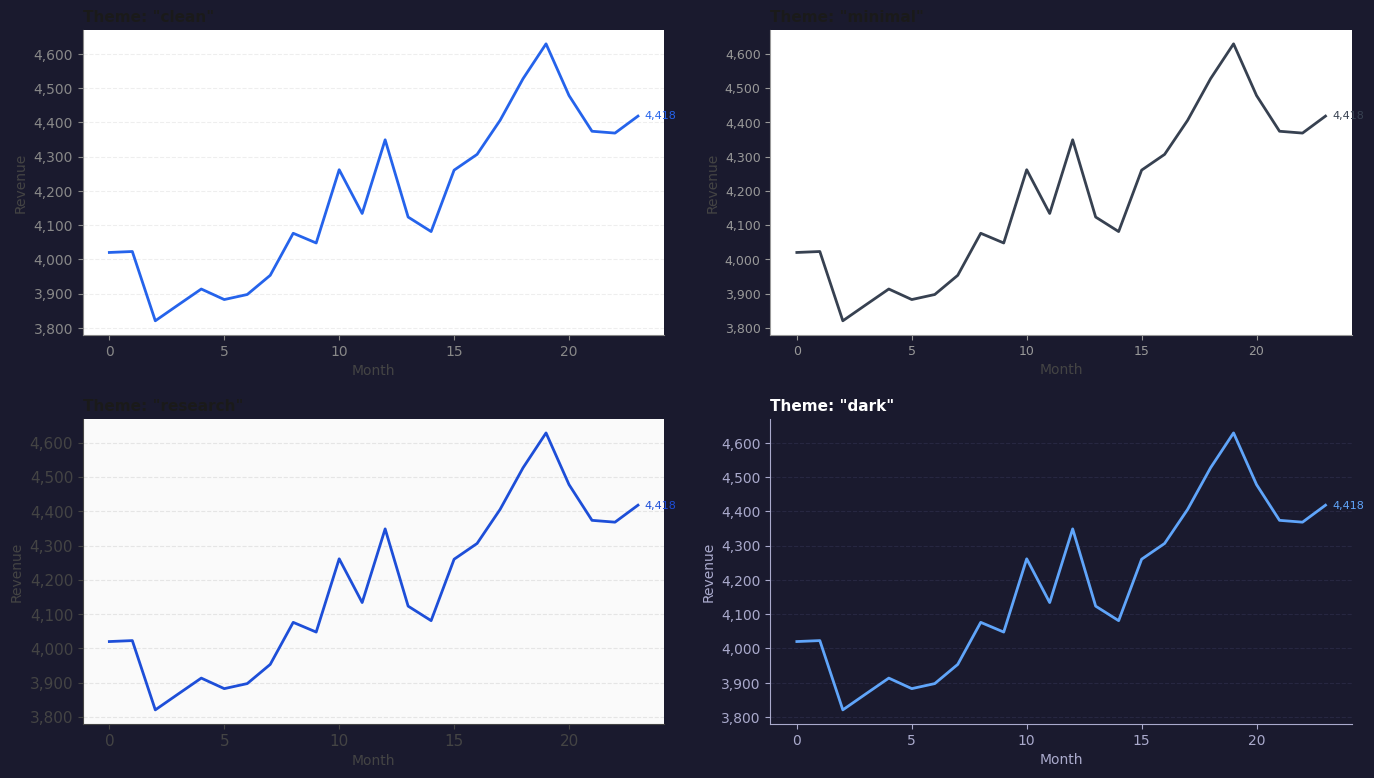

In [9]:
themes = ['clean', 'minimal', 'research', 'dark']
theme_colors = {
    'clean':    '#2563EB',
    'minimal':  '#374151',
    'research': '#1D4ED8',
    'dark':     '#60A5FA',
}
bg_colors = {
    'clean':    'white',
    'minimal':  'white',
    'research': '#fafafa',
    'dark':     '#1a1a2e',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#f0f0f0')

y_demo = list(products.values())[0]

for ax, theme in zip(axes.flatten(), themes):
    ax.set_facecolor(bg_colors[theme])
    ax.plot(months, y_demo, color=theme_colors[theme],
            linewidth=2.0)
    label_last_point(ax, months, y_demo,
                     fmt='{:,.0f}', color=theme_colors[theme], fontsize=8)
    apply_theme(ax, theme)
    ax.set_title(f'Theme: "{theme}"',
                 loc='left', fontsize=11, fontweight='bold',
                 color='white' if theme == 'dark' else '#1a1a1a')
    ax.set_xlabel('Month',
                  color='#aaaacc' if theme == 'dark' else '#444444')
    ax.set_ylabel('Revenue',
                  color='#aaaacc' if theme == 'dark' else '#444444')
    format_thousands(ax, 'y')

plt.tight_layout(pad=1.5)
plt.show()

### Theme Comparison — clean vs minimal vs research vs dark

Cùng một dataset nhưng các theme khác nhau thay đổi:

- background
- grid intensity
- spine visibility
- tick contrast
- overall mood

---

### Clean theme

Đặc điểm:

- background trắng
- grid nhẹ
- spines tối thiểu
- màu trung tính

Cảm giác:

- sạch
- cân bằng
- dễ đọc

Phù hợp:

- dashboard
- presentation
- notebook

---

### Minimal theme

Đặc điểm:

- gần như không grid
- rất ít decoration
- focus vào data
- contrast thấp

Cảm giác:

- rất sạch
- nhẹ
- storytelling

Phù hợp:

- report
- print
- slide

Data nổi bật nhất trong 4 theme.

---

### Research theme

Đặc điểm:

- background hơi off-white
- grid rõ hơn
- ticks đầy đủ
- reference mạnh

Cảm giác:

- analytic
- academic
- chính xác

Phù hợp:

- paper
- analysis
- scientific plots

Dễ đọc value hơn clean.

---

### Dark theme

Đặc điểm:

- background tối
- text sáng
- grid mờ
- line sáng

Cảm giác:

- modern
- screen-friendly
- high contrast

Phù hợp:

- dark dashboard
- presentation tối
- màn hình lớn

Giảm eye strain khi nhìn lâu.

---

### Comparison summary

Clean
cân bằng giữa readability và aesthetics

Minimal
data nổi bật nhất

Research
đọc value chính xác nhất

Dark
tối ưu cho màn hình tối

---

### Khi dùng từng theme

Use clean:

- default choice
- dashboard
- notebook

Use minimal:

- storytelling
- report
- print

Use research:

- academic
- technical analysis
- precise reading

Use dark:

- dark UI
- presentation
- night mode

---

### Theme switching

Theme chỉ thay đổi style, không đổi data:

same data
different perception

Giúp chuyển context nhanh mà không đổi code plotting.

## 8. Data-Ink Ratio (Tufte)

Edward Tufte đề xuất nguyên tắc Data-Ink Ratio:

Data-Ink Ratio = Data ink / Total ink used

Maximize data-ink ratio nghĩa là mọi ink trên chart nên encode data.
Ink không encode data là chart junk và nên loại bỏ.

---

### 8.1 Data ink vs Non-data ink

Data ink:

- data lines
- markers encode value
- bars
- filled areas
- reference lines có ý nghĩa

Non-data ink:

- background shading
- heavy grid
- box borders
- decoration
- drop shadows
- 3D effects

Chỉ data ink mang thông tin.

---

### 8.2 Data-Ink Ratio

Khái niệm:

Data-Ink Ratio tăng khi:

- giữ nguyên data ink
- giảm non-data ink

Biểu diễn:

data ink tăng
hoặc
non-data ink giảm

→ ratio tăng

---

### 8.3 Low data-ink ratio

Đặc điểm:

- background đậm
- grid dày
- nhiều spines
- markers mọi điểm
- decoration

Kết quả:

- data bị chìm
- visual noise cao
- khó đọc trend

Non-data ink chiếm phần lớn.

---

### 8.4 Medium data-ink ratio

Declutter một phần:

- grid nhẹ hơn
- bỏ bớt spines
- bỏ markers
- background trắng

Kết quả:

- data rõ hơn
- vẫn có reference
- cân bằng readability

Đây là mức phổ biến nhất.

---

### 8.5 High data-ink ratio

Minimal chart:

- gần như không grid
- không box
- không decoration
- chỉ giữ data line

Kết quả:

- data nổi bật
- chart sạch
- storytelling tốt

Data ink chiếm gần toàn bộ.

---

### 8.6 Không phải càng cao càng tốt

Sai:

- xoá hết axis
- xoá ticks
- xoá labels

Điều này làm mất context.

Đúng:

giữ ink giúp đọc data
xoá ink không encode data

---

### 8.7 Practical guideline

Remove:

- heavy grid
- background shading
- unnecessary spines
- decoration

Keep:

- data line
- axis labels
- essential ticks
- annotations quan trọng

---

### Summary

Data-Ink Ratio giúp:

- giảm visual noise
- tăng readability
- highlight data
- loại bỏ chart junk

Nguyên tắc:

giữ data ink
xoá non-data ink

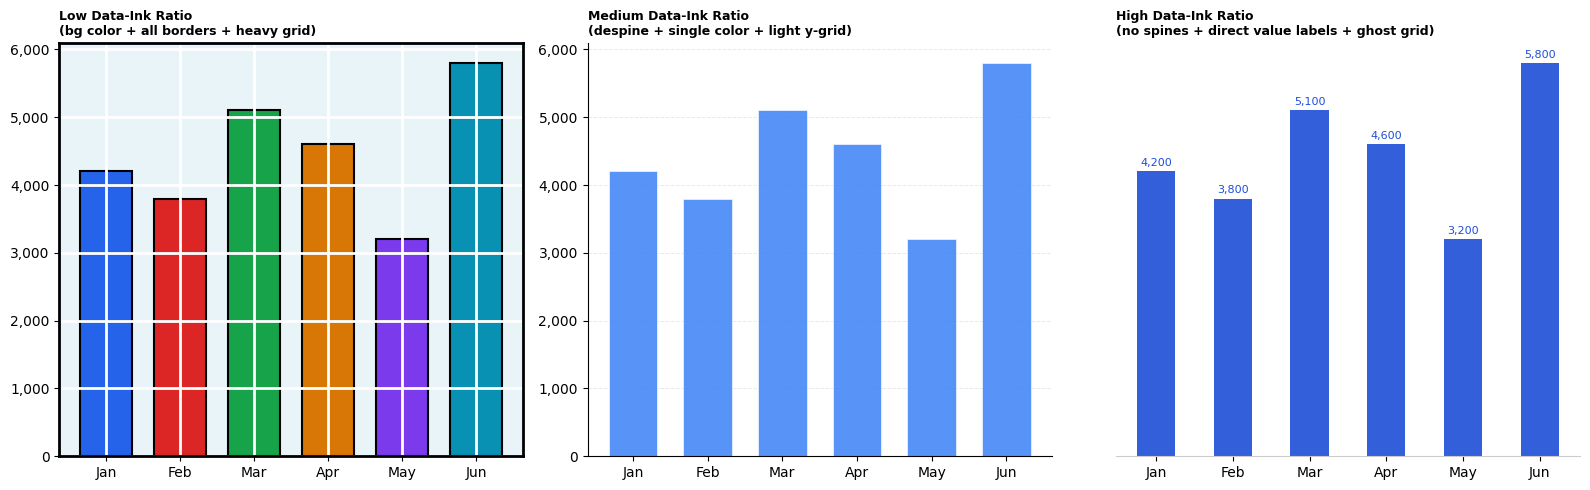

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

y_bar = np.array([4200, 3800, 5100, 4600, 3200, 5800])
cats  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
bar_colors = categorical_colors(6)

# Low ratio: every junk element
ax = axes[0]
ax.set_facecolor('#E8F4F8')
bars = ax.bar(cats, y_bar, color=bar_colors, edgecolor='black',
              linewidth=1.5, width=0.7)
# Heavy gridlines both axes
ax.grid(True, axis='both', color='white', linewidth=2.0)
# All spines visible with thick border
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_visible(True)
ax.set_title('Low Data-Ink Ratio\n(bg color + all borders + heavy grid)',
             loc='left', fontsize=9, fontweight='bold')
format_thousands(ax, 'y')

# Medium ratio
ax = axes[1]
ax.bar(cats, y_bar, color='#3B82F6', edgecolor='white',
       linewidth=0.5, width=0.65, alpha=0.85)
despine(ax)
set_grid(ax, which='y', color='#e0e0e0', linewidth=0.7)
ax.set_title('Medium Data-Ink Ratio\n(despine + single color + light y-grid)',
             loc='left', fontsize=9, fontweight='bold')
format_thousands(ax, 'y')

# High ratio: Tufte-style
ax = axes[2]
ax.bar(cats, y_bar, color='#1D4ED8', edgecolor='none',
       width=0.5, alpha=0.9)
# Only baseline
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(left=False)
ax.yaxis.grid(True, color='#f0f0f0', linewidth=0.5)
ax.set_axisbelow(True)
# Value labels directly on bars
for i, (cat, val) in enumerate(zip(cats, y_bar)):
    ax.text(i, val + 80, f'{val:,}', ha='center', fontsize=8, color='#1D4ED8')
ax.set_yticks([])  # remove y ticks entirely — values are on bars
ax.set_title('High Data-Ink Ratio\n(no spines + direct value labels + ghost grid)',
             loc='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Data-Ink Ratio — Low vs Medium vs High

Cùng một dataset nhưng mức Data-Ink Ratio khác nhau tạo chart rất khác.

---

### Low Data-Ink Ratio

Đặc điểm:

- background color đậm
- tất cả borders
- grid dày
- nhiều màu bar
- decoration

Kết quả:

- data bị chìm
- visual noise cao
- khó so sánh giá trị
- mắt bị phân tán

Non-data ink chiếm phần lớn diện tích chart.

---

### Medium Data-Ink Ratio

Declutter một phần:

- bỏ top/right spines
- single color bars
- grid nhẹ
- background trắng

Kết quả:

- data rõ hơn
- vẫn có reference
- cân bằng readability

Đây là mức phù hợp cho dashboard và notebook.

---

### High Data-Ink Ratio

Chỉ giữ ink encode data:

- không spines
- ghost grid rất nhẹ
- direct value labels
- single color

Kết quả:

- data nổi bật nhất
- đọc value ngay
- không cần nhìn trục y
- chart sạch nhất

Gần như toàn bộ ink đều encode data.

---

### Direct value labels tăng data-ink ratio

Thay vì:

- axis ticks
- grid
- reference lines

Dùng:

- label trực tiếp trên bar

Giúp:

- bỏ trục y
- giảm grid
- giảm clutter

---

### Data-Ink progression

Low:

grid + background + borders > data

Medium:

data ≈ non-data

High:

data >> non-data

---

### Khi dùng từng mức

Low:

- exploratory
- debug
- teaching

Medium:

- dashboard
- notebook
- report

High:

- presentation
- storytelling
- highlight values

---

### Summary

Tăng Data-Ink Ratio bằng cách:

- bỏ decoration
- giảm grid
- bỏ borders
- dùng direct labels
- dùng ít màu

Mục tiêu:

mọi ink trên chart phải encode data

## 9. Before / After Chart Makeover

Áp dụng toàn bộ kỹ thuật:

- declutter
- number formatting
- typography hierarchy
- inline labels
- max/min labels
- theme system
- data-ink ratio

Before:

- nhiều chart junk
- tick khó đọc
- không hierarchy
- không highlight điểm quan trọng

After:

- clean theme
- formatted numbers
- inline labels
- peak / last labels
- minimal grid
- typography rõ ràng

Kết quả:

- giảm cognitive load
- highlight message chính
- đọc nhanh hơn
- storytelling tốt hơn

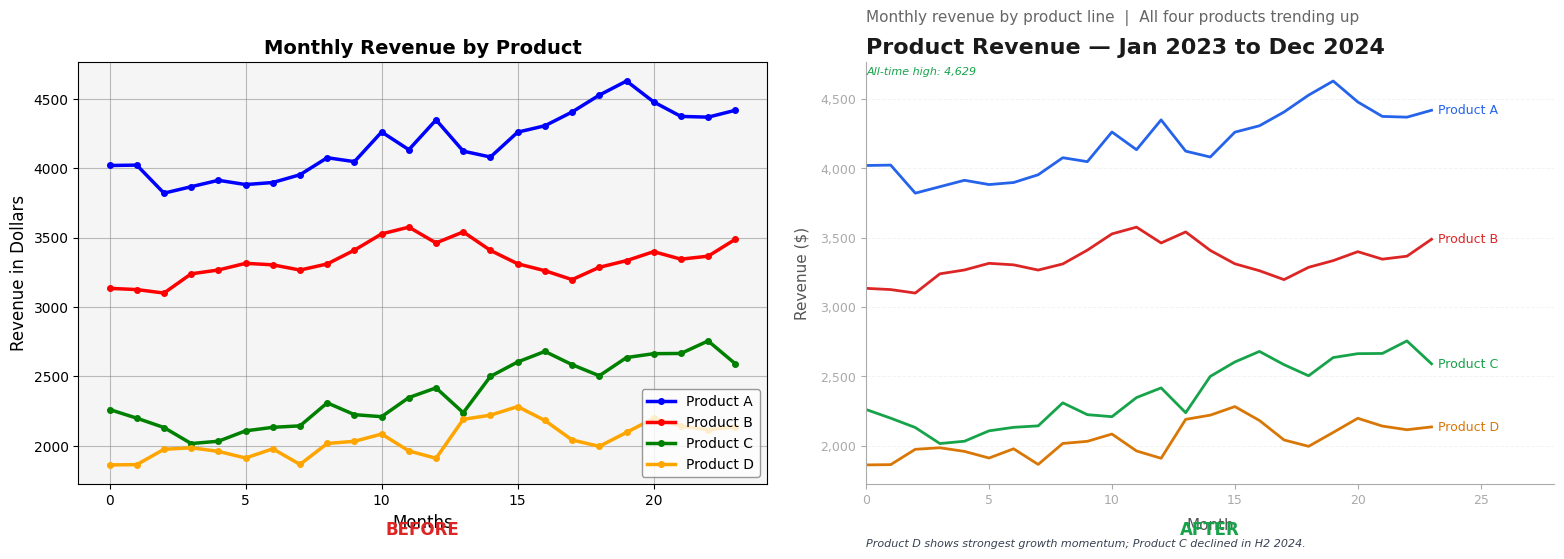

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# ── BEFORE ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#F5F5F5')

for (name, y), c in zip(products.items(), ['blue','red','green','orange']):
    ax.plot(months, y, color=c, linewidth=2.5,
            marker='o', markersize=4, label=name)

ax.legend(loc='lower right', frameon=True, fontsize=10,
          facecolor='white', edgecolor='grey')
ax.set_title('Monthly Revenue by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Months', fontsize=12)
ax.set_ylabel('Revenue in Dollars', fontsize=12)
ax.grid(True, color='grey', alpha=0.5)
ax.text(0.5, -0.12, 'BEFORE',
        transform=ax.transAxes, ha='center', fontsize=12,
        fontweight='bold', color='#DC2626')

# ── AFTER ─────────────────────────────────────────────────────────────────
ax = axes[1]

# Plot with proper colors
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0)
    label_last_point(ax, months, y, text=name, color=c, fontsize=9, offset_x=5)

# Highlight overall max
all_y = np.concatenate(list(products.values()))
global_max = all_y.max()
ax.annotate(f'All-time high: {global_max:,.0f}',
            xy=(0, 0.97), xycoords='axes fraction',
            fontsize=8, color='#16A34A', style='italic')

# Clean styling
despine(ax)
set_grid(ax, which='y', color='#eeeeee', linewidth=0.7)
format_thousands(ax, 'y')
set_tick_style(ax, color='#aaaaaa', labelsize=9)
set_axis_labels(ax, xlabel='Month', ylabel='Revenue ($)',
                fontsize=AXIS_LABEL_SIZE, color='#555555')

# Expand x for labels
ax.set_xlim(months[0], months[-1] + 5)

# Title + subtitle via ChartBuilder style
ax.set_title('Product Revenue — Jan 2023 to Dec 2024',
             loc='left', fontsize=TITLE_SIZE, fontweight='bold', color='#1a1a1a')
ax.annotate('Monthly revenue by product line  |  All four products trending up',
            xy=(0, 1), xycoords='axes fraction',
            xytext=(0, 26), textcoords='offset points',
            fontsize=SUBTITLE_SIZE - 1, color='#666666', va='bottom')

add_caption(ax,
    'Product D shows strongest growth momentum; Product C declined in H2 2024.',
    y=-0.13, fontsize=CAPTION_SIZE,
)

ax.text(0.5, -0.12, 'AFTER',
        transform=ax.transAxes, ha='center', fontsize=12,
        fontweight='bold', color='#16A34A')

plt.tight_layout(pad=2.0)
plt.show()

### Before vs After — Chart Makeover

Before:

- heavy grid
- legend xa dữ liệu
- tick labels mặc định
- không highlight điểm quan trọng
- typography phẳng

After:

- clean theme + light grid
- inline series labels
- max / last value labels
- typography hierarchy rõ
- declutter + tăng data-ink ratio

Kết quả:

- giảm visual noise
- đọc nhanh hơn
- so sánh series dễ hơn
- message rõ ràng hơn

---
## Summary — Cognitive Load Reduction Checklist

| Action | Function / Method | Cognitive Benefit |
|--------|------------------|------------------|
| Xóa legend | `label_last_point` | Loại bỏ round-trip eye movement |
| Inline label | `inline_series_labels` | Label gần data |
| Label max/min | `label_max`, `label_min` | Surface key values tự động |
| Remove spines | `despine(ax)` | Giảm visual noise |
| Light grid | `set_grid(ax, color='#eee')` | Grid hỗ trợ, không lấn át |
| Format numbers | `format_thousands`, `format_percent` | Đọc nhanh hơn |
| Font hierarchy | `TITLE_SIZE`, `CAPTION_SIZE`, ... | Reading order tự nhiên |
| Theme | `apply_theme(ax, 'clean')` | Consistent base styling |
| High data-ink | Remove markers, bg, borders | Chỉ giữ lại ink encode data |
| Caption | `add_caption` | Takeaway không cần suy luận |

---

### Key Takeaway

> Cognitive load reduction không phải là làm chart đơn giản hơn.
> Nó là **bỏ đi mọi thứ không encode thông tin** để
> mọi ink còn lại đều có lý do tồn tại.
>
> Chart tốt nhất là chart mà người xem hiểu được insight
> **trước khi họ kịp nhận ra rằng họ đang đọc một chart**.

**Next →** `06_process_and_journey.ipynb` — Khi data là một quy trình: waterfall, contribution, và decomposition.